In [1]:
import os
import numpy as np
import scipy.io as sio
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from utils import calculate_rdc, calculate_mcc, plot_sq

In [2]:
res_dir = "/data/users4/xli/MSIVA/MSIVA/results"
sz_smri_data_path = os.path.join(res_dir, "mat", "mancovaOuts_allHCSZ_combinedRelatives_wX_preregSite_C30_SMRI_GICAinit.mat")
sz_smri_data = sio.loadmat(sz_smri_data_path)['NMODELHCSZ0ns']
sz_smri_data_array = sz_smri_data[0][0][0]
age = sz_smri_data_array[:,0]
sex = sz_smri_data_array[:,1]
diagnosis = sz_smri_data_array[:,2]
id = sio.loadmat(os.path.join(res_dir, "mat", "SZID.mat"))['ID'][0] - 1

In [ ]:
img_dir = os.path.join(res_dir, "img")
subspace_struct_list = ["s1", "s2", "s3", "s4", "s5"]
num_subspace_struct=len(subspace_struct_list)

Y = np.zeros((num_subspace_struct,3,2,12,999)) # S1-4, UA/MSIVA/GICA, M1-2, voxel, source
W = np.zeros((num_subspace_struct,3,2,12,44318)) # S1-4, UA/MSIVA/GICA, M1-2, voxel, source

num_iter=21
corr = np.zeros((num_subspace_struct,9,12,12))

for i,ss in enumerate(subspace_struct_list):

    data = sio.loadmat(os.path.join(img_dir, ss, "um_neuroimaging_sz_Y.mat"))
    Y1 = np.squeeze(data['Y1'])

    data = sio.loadmat(os.path.join(img_dir, ss, "ummm_neuroimaging_sz_Y.mat"))
    Y2 = np.squeeze(data['Y2'])

    data = sio.loadmat(os.path.join(img_dir, ss, "mm_neuroimaging_sz_Y.mat"))
    Y3 = np.squeeze(data['Y3'])

    Y[i,0,0] = Y1[0][:,id]
    Y[i,0,1] = Y1[1][:,id]
    Y[i,1,0] = Y2[0][:,id]
    Y[i,1,1] = Y2[1][:,id]
    Y[i,2,0] = Y3[0][:,id]
    Y[i,2,1] = Y3[1][:,id]

    data = sio.loadmat(os.path.join(img_dir, ss, "um_neuroimaging_sz_W.mat"))
    W1 = np.squeeze(data['W1'])

    data = sio.loadmat(os.path.join(img_dir, ss, "ummm_neuroimaging_sz_W.mat"))
    W2 = np.squeeze(data['W2'])

    data = sio.loadmat(os.path.join(img_dir, ss, "mm_neuroimaging_sz_W.mat"))
    W3 = np.squeeze(data['W3'])

    W[i,0,0] = W1[0]
    W[i,0,1] = W1[1]
    W[i,1,0] = W2[0]
    W[i,1,1] = W2[1]
    W[i,2,0] = W3[0]
    W[i,2,1] = W3[1]

    corr[i,0] = calculate_rdc(Y1[0],Y1[0])
    corr[i,1] = calculate_rdc(Y1[1],Y1[1])
    corr[i,2] = calculate_rdc(Y1[0],Y1[1])

    corr[i,3] = calculate_rdc(Y2[0],Y2[0])
    corr[i,4] = calculate_rdc(Y2[1],Y2[1])
    corr[i,5] = calculate_rdc(Y2[0],Y2[1])

    corr[i,6] = calculate_rdc(Y3[0],Y3[0])
    corr[i,7] = calculate_rdc(Y3[1],Y3[1])
    corr[i,8] = calculate_rdc(Y3[0],Y3[1])

sio.savemat(os.path.join(res_dir, "mat", "rdc_sz.mat"), {"corr": corr})
# corr = sio.loadmat(os.path.join(res_dir, "mat", "rdc_sz.mat"))["corr"]

In [4]:
val = 1
num_source = 12

# S1
num_unique_source = 3
s1 = np.zeros((num_source, num_source))
s1[:2,:2] = val
s1[2:5,2:5] = val*2
s1[5:9,5:9] = val*3

# S2
num_unique_source = 2
s2 = np.zeros((num_source, num_source))
s2[:2,:2] = val
s2[2:4,2:4] = val*2
s2[4:6,4:6] = val*3
s2[6:8,6:8] = val*4
s2[8:10,8:10] = val*5

# S3
num_unique_source = 3
s3 = np.zeros((num_source, num_source))
s3[:3,:3] = val
s3[3:6,3:6] = val*2
s3[6:9,6:9] = val*3

# S4
num_unique_source = 4
s4 = np.zeros((num_source, num_source))
s4[:4,:4] = val
s4[4:8,4:8] = val*2

# S5
num_unique_source = 4
s5 = np.zeros((num_source, num_source))
for i in range(12):
    s5[i,i] = val*(i+1)

s_list = [s1, s2, s3, s4, s5]

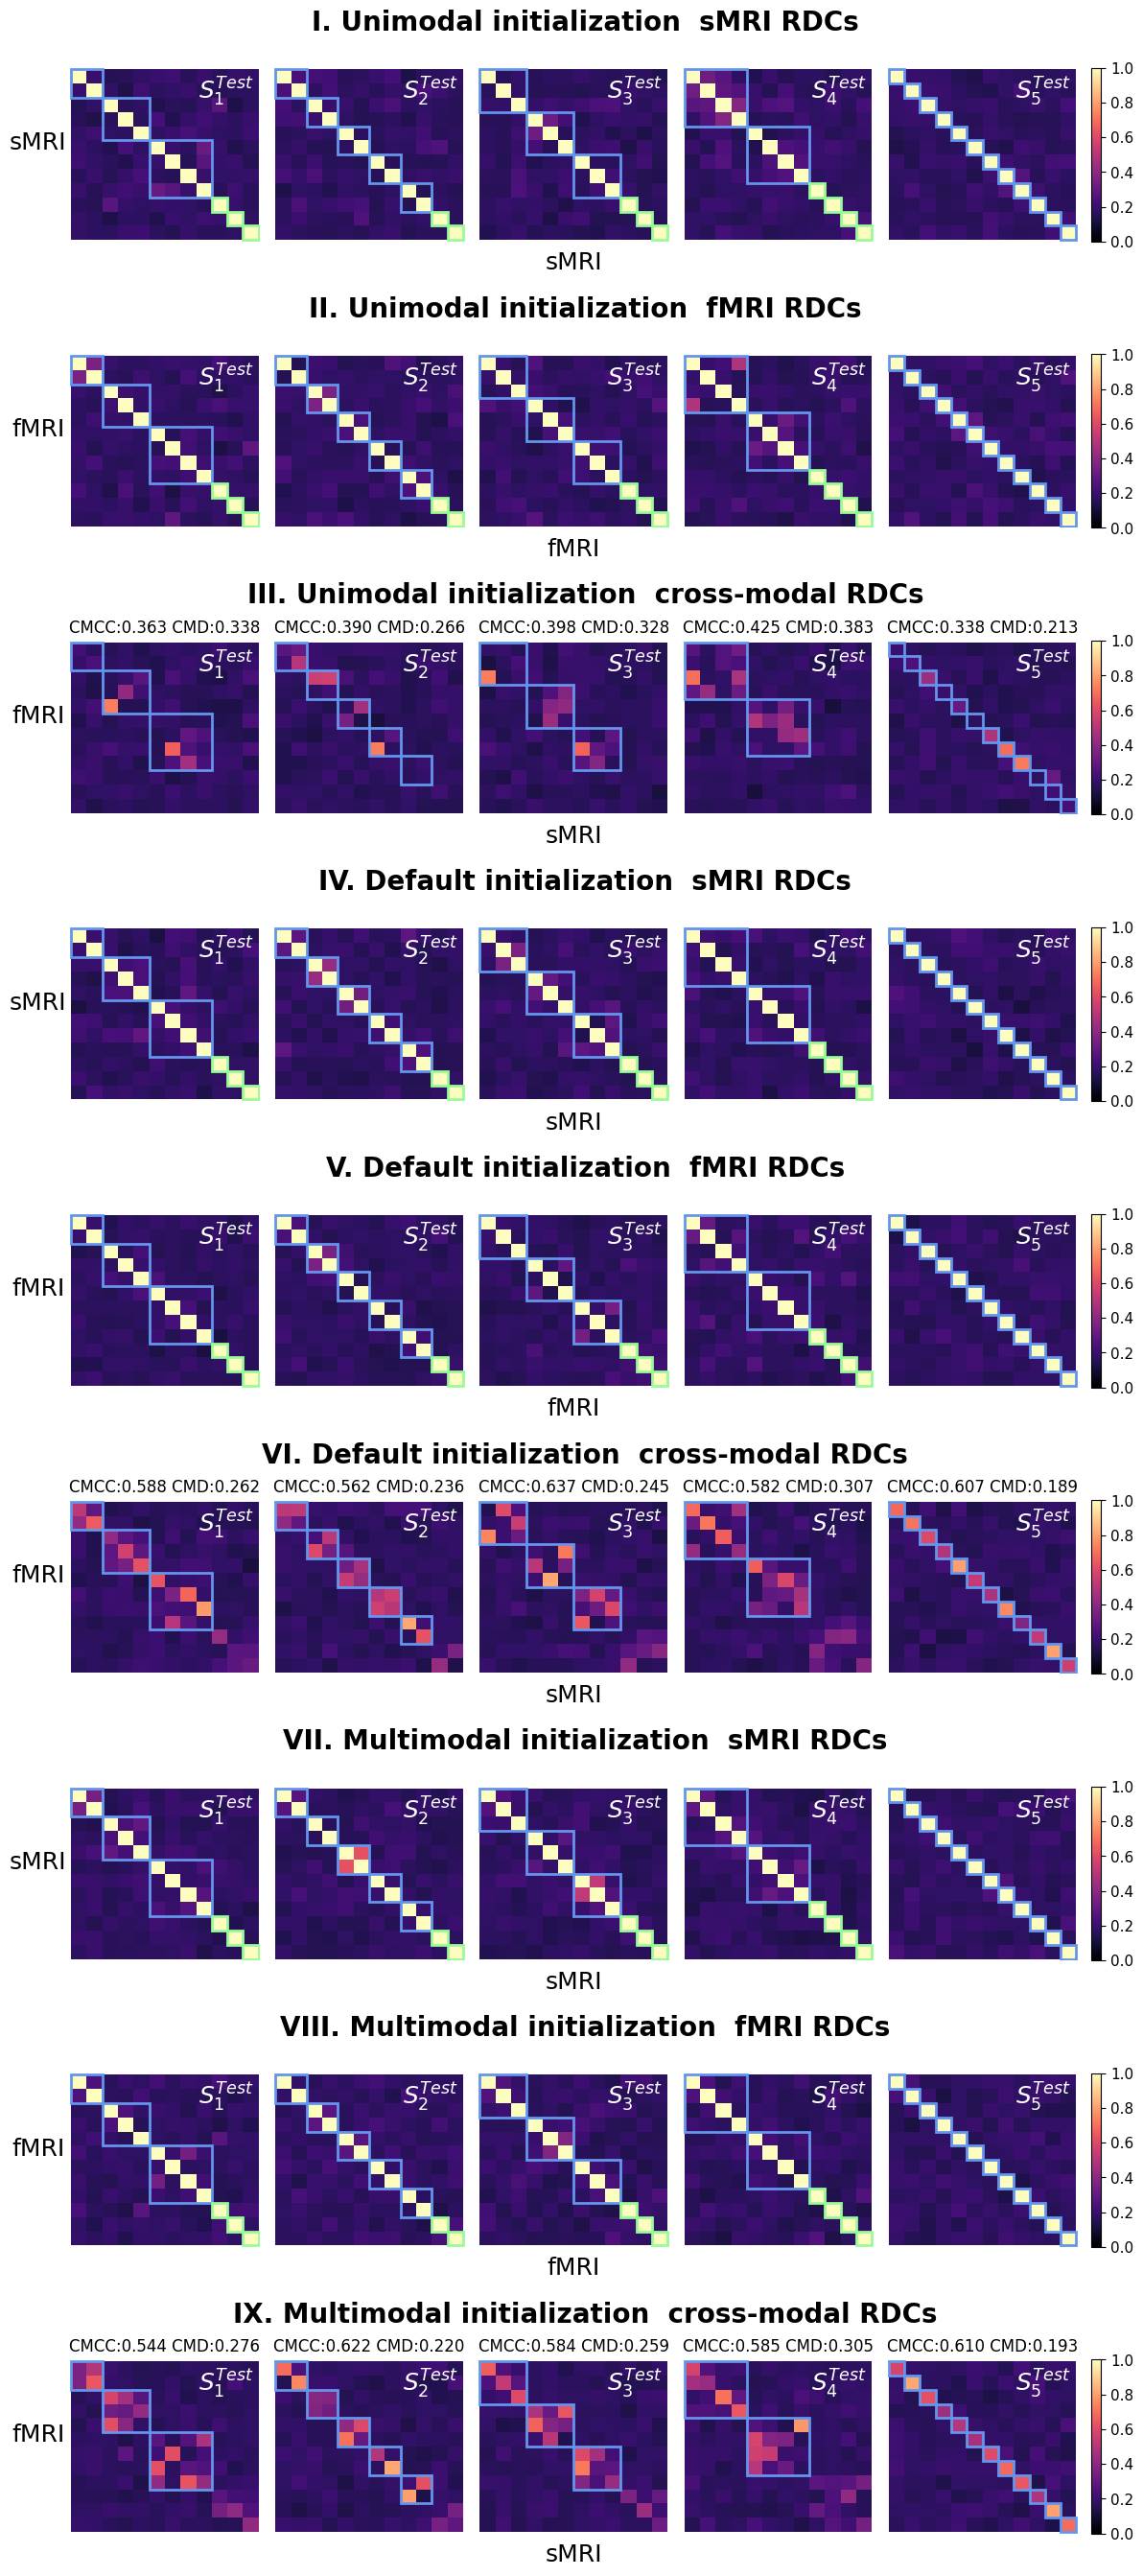

In [ ]:
analysis_list = ["I. Unimodal initialization  sMRI RDCs",
                 "II. Unimodal initialization  fMRI RDCs",
                 "III. Unimodal initialization  cross-modal RDCs",
                 "IV. Default initialization  sMRI RDCs",
                 "V. Default initialization  fMRI RDCs",
                 "VI. Default initialization  cross-modal RDCs",
                 "VII. Multimodal initialization  sMRI RDCs",
                 "VIII. Multimodal initialization  fMRI RDCs",
                 "IX. Multimodal initialization  cross-modal RDCs"]
modality_list = ["sMRI", "fMRI"]
subspace_dict = {"S1": [2, 3, 4], "S2": [2, 2, 2, 2, 2], "S3": [3, 3, 3], "S4": [4, 4], "S5": [1]*12}

n_row = 9

fig, axes = plt.subplots(n_row, num_subspace_struct + 1, figsize = (2.4 * num_subspace_struct, 3 * n_row), gridspec_kw = {'width_ratios': [1, 1, 1, 1, 1, 0.05]})

for i in range(num_subspace_struct):
    ss = subspace_dict[f"S{i+1}"]
    for j in range(n_row):
        ax = axes[j,i]
        abscorr = np.abs(corr[i,j])
        if j in [2, 5, 8]:
            mcc, md, aggcorr, _ = calculate_mcc(abscorr, ss, sort=False)
            sns.heatmap(abscorr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
            ax.text(9.9, 1.6, f"$S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
            ax.set_title(f"CMCC:{mcc:.3f} CMD:{md:.3f}", fontsize=12)
            if i == 2:
              ax.set_xlabel("sMRI", fontsize=18)
            if i == 0:
              ax.set_ylabel("fMRI", fontsize=18, rotation=0, labelpad=20)
            plot_sq(ax, i, crossmodal=True)
            ax.set_xlim(-0.1, 12.1)
            ax.set_ylim(12.1, -0.1)
        else:
            mcc = np.mean(np.diag(abscorr))
            sns.heatmap(abscorr, cmap="magma", vmin=0, vmax=1, ax=ax, cbar=False)
            ax.text(9.9, 1.6, f"$S_{i+1}^{{Test}}$", fontsize=18, color="white", ha="center", va="center")
            if i == 2:
               ax.set_xlabel(f"{modality_list[j%3]}", fontsize=18)
            if i == 0:
              ax.set_ylabel(f"{modality_list[j%3]}", fontsize=18, rotation=0, labelpad=20)
            plot_sq(ax, i)
            ax.set_xlim(-0.1, 12.1)
            ax.set_ylim(12.1, -0.1)
        ax.set_xticks([])
        ax.set_yticks([])

norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap="magma", norm=norm)

for i in range(n_row):
    ax = fig.add_subplot(n_row, 1, i+1)
    ax.set_title(analysis_list[i], fontsize=20, fontweight='bold', pad=28)
    ax.axis('off')
    cbar = fig.colorbar(sm, cax=axes[i, 5])
    cbar.ax.tick_params(labelsize=11)

plt.tight_layout(pad=1, h_pad=0, w_pad=1)
plt.savefig("figures/neuroimaging_sz_rdc.pdf")